## 0. 설정

In [1]:
<< mTensor`

In [2]:
$PreRead = 
  ReplaceAll[#, 
    expr_String :> StringReplace[expr,
    "TMP" -> "mTensor`Private"]] &;

In [3]:
DefineKind[Alphabet["Greek"], Greek]; DefineKind[
 ToUpperCase /@ Alphabet[], Capital]

## 1. Tensor Operations

In [4]:
Tdefine[T, "ba"]; Tdefine[F, "-ba"];
Tdefine[v, "a"]; Tdefine[\[Xi], "a"]; Tdefine[f[]]

### 1.1 CDtoGamma

Covariant derivative를 Affine connection으로 변환한다. 옵션으로 공변 도함수의 이름이 있다.

공식:
$$
  \nabla_a T_b^{\ c} = \hat{\partial}_a T_b^{\ c}
  - \Gamma_{ab}^{\ \ p} T_p^{\ c}
  + \Gamma_{ap}^{\ \ c} T_b^{\ p}
$$

In [6]:
CD[la, F[lb, lc]]

CD[la, F[lb, lc]]

In [7]:
CDtoGamma[%]

BD[la, F[lb, lc]] - F[ld, lc] GammaCD[la, lb, ud] - F[lb, ld] GammaCD[la, lc, ud]

In [8]:
CD[la, lb, v[uc]] - CD[lb, la, v[uc]]

CD[la, CD[lb, v[uc]]] - CD[lb, CD[la, v[uc]]]

In [9]:
CDtoGamma[%]

BD[la, CD[lb, v[uc]]] - BD[lb, CD[la, v[uc]]] - CD[ld, v[uc]] GammaCD[la, lb, ud] + 
 
>   CD[lb, v[ud]] GammaCD[la, ld, uc] + CD[ld, v[uc]] GammaCD[lb, la, ud] - 
 
>   CD[la, v[ud]] GammaCD[lb, ld, uc]

In [10]:
CDtoGamma[%]

BD[la, BD[lb, v[uc]]] - BD[lb, BD[la, v[uc]]] - BD[ld, v[uc]] GammaCD[la, lb, ud] + 
 
>   BD[ld, v[uc]] GammaCD[lb, la, ud] + BD[la, GammaCD[lb, ld, uc]] v[ud] - 
 
>   BD[lb, GammaCD[la, ld, uc]] v[ud] - GammaCD[la, le, ud] GammaCD[lb, ld, uc] v[ue] + 
 
>   GammaCD[la, ld, uc] GammaCD[lb, le, ud] v[ue] - 
 
>   GammaCD[la, lb, ud] GammaCD[ld, le, uc] v[ue] + 
 
>   GammaCD[lb, la, ud] GammaCD[ld, le, uc] v[ue]

텐서가 아닌 표현의 Lie derivative는 의미가 없으므로 LD 안에 있는 CD는 변환되지 않는다.

In [11]:
LD[v, CD[la, F[lb, lc]]]

LD[v, CD[la, F[lb, lc]]]

In [12]:
CDtoGamma[%]

LD[v, CD[la, F[lb, lc]]]

옵션으로 공변 도함수의 이름이 있다.

In [13]:
SetDefaultKind[Capital]

In [14]:
DefineDerivativeOperator[CovD, "\[ScriptCapitalD]", Greek]

In [15]:
Tdefine[V[l\[Mu]], "a"]

In [16]:
{CovD[l\[Mu], v[u\[Nu]]], CovD[l\[Mu], V[u\[Nu]]]}

{CovD[lμ, v[uν]], CovD[lμ, V[uν]]}

In [17]:
CDtoGamma[#, CovD] & /@ % // ResetDummies

{BD[lμ, v[uν]], BD[lμ, V[uν]] + GammaCovD[lμ, lα, uν] V[uα]}

In [18]:
RemoveObject[V]; RemoveDerivativeOperator[CovD]

In [19]:
SetDefaultKind[Latin]

### 1.2 CommuteCD

Covariant derivative가 두 번 이상 연속해서 작용할 때, 원래의 표현과 같으면서 두 CovD의 인덱스를 교환시킨 표현을 준다. 첫 번째 인자는 뒤 바꿀 두 개의 인덱스로 이루어진 리스트이고, 두 번째 인자는 임의의 표현이다. 옵션으로 공변 도함수의 이름이 있다.

공식:
$$
  (\nabla_a \nabla_b - \nabla_b \nabla_a + t_{ab}^{\ \ c}) T_c^{\ d}
  = (\textrm{riemannSign}) (R_{abc}^{\ \ \ \ \ p} T_p^{\ d}
  - R_{abp}^{\ \ \ \ \ d} T_c^{\ p})
$$

Torsion-Free가 아닌 경우:

In [20]:
TorsionFreeQ[CD] = False;

In [21]:
expr = CD[la, lb, T[lc, ud]]

CD[la, CD[lb, T[lc, ud]]]

In [22]:
CommuteCD[{la, lb}, expr]

CD[lb, CD[la, T[lc, ud]]] - RiemannCD[la, lb, le, ud] T[lc, ue] + 
 
>   RiemannCD[la, lb, lc, ue] T[le, ud] - CD[le, T[lc, ud]] Torsion[la, lb, ue]

Torsion-Free인 경우:

In [23]:
TorsionFreeQ[CD] = True;

In [24]:
CommuteCD[{la, lb}, expr]

CD[lb, CD[la, T[lc, ud]]] - RiemannCD[la, lb, le, ud] T[lc, ue] + 
 
>   RiemannCD[la, lb, lc, ue] T[le, ud]

In [25]:
expr = CD[la, ub, lc, F[lb, ud]]

CD[la, CD[ub, CD[lc, F[lb, ud]]]]

In [26]:
CommuteCD[{la, ub}, expr]

CD[ub, CD[la, CD[lc, F[lb, ud]]]] - CD[lc, F[lb, ud]] RicciCD[la, ub] + 
 
>   CD[le, F[lb, ud]] RiemannCD[la, ub, lc, ue] - 
 
>   CD[lc, F[lb, ue]] RiemannCD[la, ub, le, ud]

뒤 바꿀 두 개의 인덱스는 연속해서 있어야 한다.

In [27]:
CommuteCD[{la, lc}, expr]

CD[la, CD[ub, CD[lc, F[lb, ud]]]]

In [28]:
CommuteCD[{lc, ub}, expr]

CD[la, CD[lc, CD[ub, F[lb, ud]]]] + CD[la, RicciCD[lc, ub]] F[lb, ud] - 
 
>   CD[la, RiemannCD[ub, lc, le, ud]] F[lb, ue] + CD[la, F[lb, ud]] RicciCD[lc, ub] - 
 
>   CD[la, F[lb, ue]] RiemannCD[ub, lc, le, ud]

In [29]:
CommuteCD[{la, ub}, F[uc, le] expr]

CD[ub, CD[la, CD[lc, F[lb, ud]]]] F[uc, le] - 
 
>   CD[lc, F[lb, ud]] F[uc, le] RicciCD[la, ub] + 
 
>   CD[lf, F[lb, ud]] F[uc, le] RiemannCD[la, ub, lc, uf] - 
 
>   CD[lc, F[lb, uf]] F[uc, le] RiemannCD[la, ub, lf, ud]

In [30]:
CommuteCD[{la, lb}, CD[la, lb, v[uc]]]

CD[lb, CD[la, v[uc]]] - RiemannCD[la, lb, ld, uc] v[ud]

In [31]:
CommuteCD[{la, lb}, CD[la, lb, f[]]]

CD[lb, CD[la, f[]]]

CD의 인덱스가 아니면 영향이 없다.

In [32]:
expr = CD[la, BD[ub, CD[lc, F[lb, ud]]]]

CD[la, BD[ub, CD[lc, F[lb, ud]]]]

In [33]:
CommuteCD[{la, ub}, expr]

CD[la, BD[ub, CD[lc, F[lb, ud]]]]

텐서 표현이 아닌 것에도 영향이 없다.

In [34]:
expr = CD[la, ld, BD[ub, CD[lc, F[lb, ud]]]]

CD[la, CD[ld, BD[ub, CD[lc, F[lb, ud]]]]]

In [35]:
CommuteCD[{lb, ud}, expr]

CD[la, CD[ld, BD[ub, CD[lc, F[lb, ud]]]]]

옵션으로 공변 도함수의 이름이 있다.

In [36]:
SetDefaultKind[Capital]

In [37]:
DefineDerivativeOperator[CovD, "\[ScriptCapitalD]", Capital, 
 TorsionFreeQ -> False]

In [38]:
Tdefine[V[lA], "a"]

In [39]:
{CovD[lA, lB, v[uC]], CovD[lA, lB, V[uC]]}

{CovD[lA, CovD[lB, v[uC]]], CovD[lA, CovD[lB, V[uC]]]}

In [40]:
CommuteCD[{lA, lB}, #, CovD] & /@ % // ResetDummies

{CovD[lB, CovD[lA, v[uC]]] - CovD[lD, v[uC]] Torsion[lA, lB, uD], 
 
>   CovD[lB, CovD[lA, V[uC]]] - CovD[lD, V[uC]] Torsion[lA, lB, uD] - 
 
>    RiemannCovD[lA, lB, lD, uC] V[uD]}

In [41]:
RemoveObject[V]; RemoveDerivativeOperator[CovD]

In [42]:
SetDefaultKind[Latin]

### 1.3 GammaToMetric

임의의 표현에 있는 metric-connection $\Gamma_{ab}^{\ \ c}$를 계량 텐서로 변환한다. 옵션으로 공변 도함수의 이름이 있다.

공식:
\begin{gather*}
  \Gamma_{ab}^{\ \ c} \equiv g^{cd} \Gamma_{abd} \\
  \Gamma_{abc} = \frac{1}{2} (\hat{\partial}_a g_{bc}
  + \hat{\partial}_b g_{ac} - \hat{\partial}_c g_{ab}
  + f_{abc} + f_{cab} + f_{cba}
  + t_{abc} + t_{cab} + t_{cba})
\end{gather*}

Torsion-Free가 아니고 Non-coordinate basis에서:

In [43]:
TorsionFreeQ[CD] = False;

In [44]:
Off[CoordinateBasisFlag]

BD[la, Metricg[lb, lc]]   BD[lb, Metricg[la, lc]]   BD[lc, Metricg[la, lb]]
----------------------- + ----------------------- - ----------------------- + 
           2                         2                         2
 
    Structuref[la, lb, lc]   Structuref[lc, la, lb]   Structuref[lc, lb, la]
>   ---------------------- + ---------------------- + ---------------------- + 
              2                        2                        2
 
    Torsion[la, lb, lc]   Torsion[lc, la, lb]   Torsion[lc, lb, la]
>   ------------------- + ------------------- + -------------------
             2                     2                     2
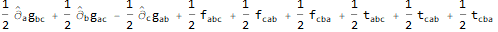

In [45]:
GammaToMetric[GammaCD[la, lb, lc]]

Torsion-Free가 아니고 Non-coordinate basis에서

In [46]:
On[CoordinateBasisFlag]

BD[la, Metricg[lb, lc]]   BD[lb, Metricg[la, lc]]   BD[lc, Metricg[la, lb]]
----------------------- + ----------------------- - ----------------------- + 
           2                         2                         2
 
    Torsion[la, lb, lc]   Torsion[lc, la, lb]   Torsion[lc, lb, la]
>   ------------------- + ------------------- + -------------------
             2                     2                     2
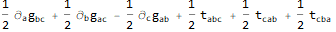

In [47]:
GammaToMetric[GammaCD[la, lb, lc]]

Torsion-Free이고 Coordinate basis에서

In [48]:
TorsionFreeQ[CD] = True;

BD[la, Metricg[lb, lc]]   BD[lb, Metricg[la, lc]]   BD[lc, Metricg[la, lb]]
----------------------- + ----------------------- - -----------------------
           2                         2                         2
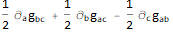

In [49]:
GammaToMetric[GammaCD[la, lb, lc]]

BD[la, Metricg[lb, ld]] Metricg[uc, ud]   BD[lb, Metricg[la, ld]] Metricg[uc, ud]
--------------------------------------- + --------------------------------------- - 
                   2                                         2
 
    BD[ld, Metricg[la, lb]] Metricg[uc, ud]
>   ---------------------------------------
                       2
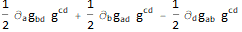

In [50]:
GammaToMetric[GammaCD[la, lb, uc]]

BD[la, Metricg[ld, lc]] Metricg[ub, ud]   BD[lc, Metricg[la, ld]] Metricg[ub, ud]
--------------------------------------- - --------------------------------------- + 
                   2                                         2
 
    BD[ld, Metricg[la, lc]] Metricg[ub, ud]
>   ---------------------------------------
                       2
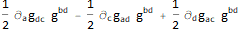

In [51]:
GammaToMetric[GammaCD[la, ub, lc]]

BD[la, Metricg[ld, lc]] Metricg[ub, ud]   BD[lc, Metricg[la, ld]] Metricg[ub, ud]
--------------------------------------- - --------------------------------------- + 
                   2                                         2
 
    BD[ld, Metricg[la, lc]] Metricg[ub, ud]
>   ---------------------------------------
                       2
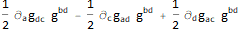

In [52]:
GammaToMetric[GammaCD[la, ub, lc]]

BD[lb, Metricg[ld, lc]] Metricg[ua, ud]   BD[lc, Metricg[ld, lb]] Metricg[ua, ud]
--------------------------------------- - --------------------------------------- + 
                   2                                         2
 
    BD[ld, Metricg[lb, lc]] Metricg[ua, ud]
>   ---------------------------------------
                       2
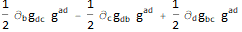

In [53]:
GammaToMetric[GammaCD[ua, lb, lc]]

-(BD[ld, Metricg[le, lb]] Metricg[ua, ue] Metricg[uc, ud])
---------------------------------------------------------- + 
                            2
 
    BD[lb, Metricg[ld, le]] Metricg[ua, ud] Metricg[uc, ue]
>   ------------------------------------------------------- + 
                               2
 
    BD[ld, Metricg[lb, le]] Metricg[ua, ud] Metricg[uc, ue]
>   -------------------------------------------------------
                               2
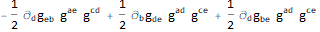

In [54]:
GammaToMetric[GammaCD[ua, lb, uc]]

BD[ld, Metricg[le, lc]] Metricg[ua, ue] Metricg[ub, ud]
------------------------------------------------------- - 
                           2
 
    BD[lc, Metricg[ld, le]] Metricg[ua, ud] Metricg[ub, ue]
>   ------------------------------------------------------- + 
                               2
 
    BD[ld, Metricg[le, lc]] Metricg[ua, ud] Metricg[ub, ue]
>   -------------------------------------------------------
                               2
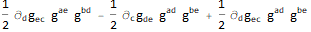

In [55]:
GammaToMetric[GammaCD[ua, ub, lc]]

-(BD[ld, Metricg[le, lf]] Metricg[ua, ue] Metricg[ub, uf] Metricg[uc, ud])
-------------------------------------------------------------------------- + 
                                    2
 
    BD[ld, Metricg[le, lf]] Metricg[ua, ue] Metricg[ub, ud] Metricg[uc, uf]
>   ----------------------------------------------------------------------- + 
                                       2
 
    BD[ld, Metricg[le, lf]] Metricg[ua, ud] Metricg[ub, ue] Metricg[uc, uf]
>   -----------------------------------------------------------------------
                                       2
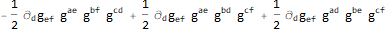

In [56]:
GammaToMetric[GammaCD[ua, ub, uc]]

Covariant derivative를 `AffineCD`로 변환한 후 다시 `Matricg`로 변환시키는 경우

In [57]:
CD[la, lb, F[ua, ub]]

CD[la, CD[lb, F[ua, ub]]]

In [58]:
CDtoGamma[%]

BD[la, CD[lb, F[ua, ub]]] + CD[lb, F[uc, ub]] GammaCD[la, lc, ua]

In [59]:
CDtoGamma[%]

BD[la, BD[lb, F[ua, ub]]] + BD[la, GammaCD[lb, lc, ub]] F[ua, uc] + 
 
>   BD[la, GammaCD[lb, lc, ua]] F[uc, ub] + BD[lb, F[uc, ub]] GammaCD[la, lc, ua] + 
 
>   BD[la, F[uc, ub]] GammaCD[lb, lc, ua] + BD[la, F[ua, uc]] GammaCD[lb, lc, ub] + 
 
>   F[uc, ud] GammaCD[la, lc, ua] GammaCD[lb, ld, ub] + 
 
>   F[ud, ub] GammaCD[la, lc, ua] GammaCD[lb, ld, uc]

BD[la, Metricg[ub, ud]] BD[lb, Metricg[lc, ld]] F[ua, uc]
BD[la, BD[lb, F[ua, ub]]] + --------------------------------------------------------- + 
                                                        2
 
    BD[la, Metricg[ub, ud]] BD[lc, Metricg[lb, ld]] F[ua, uc]
>   --------------------------------------------------------- - 
                                2
 
    BD[la, Metricg[ub, ud]] BD[ld, Metricg[lb, lc]] F[ua, uc]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, Metricg[ua, ud]] BD[lb, Metricg[lc, ld]] F[uc, ub]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, Metricg[ua, ud]] BD[lc, Metricg[lb, ld]] F[uc, ub]
>   --------------------------------------------------------- - 
                                2
 
    BD[la, Metricg[ua, ud]] BD[ld, Metricg[lb, lc]] F[uc, ub]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, Metricg[lc, ld]] BD[lb, F[uc, ub]] Metricg[ua, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, F[uc, ub]] BD[lb, Metricg[lc, ld]] Metricg[ua, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[lb, F[uc, ub]] BD[lc, Metricg[la, ld]] Metricg[ua, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, F[uc, ub]] BD[lc, Metricg[lb, ld]] Metricg[ua, ud]
>   --------------------------------------------------------- - 
                                2
 
    BD[lb, F[uc, ub]] BD[ld, Metricg[la, lc]] Metricg[ua, ud]
>   --------------------------------------------------------- - 
                                2
 
    BD[la, F[uc, ub]] BD[ld, Metricg[lb, lc]] Metricg[ua, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, BD[lb, Metricg[lc, ld]]] F[uc, ub] Metricg[ua, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, BD[lc, Metricg[lb, ld]]] F[uc, ub] Metricg[ua, ud]
>   --------------------------------------------------------- - 
                                2
 
    BD[la, BD[ld, Metricg[lb, lc]]] F[uc, ub] Metricg[ua, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, F[ua, uc]] BD[lb, Metricg[lc, ld]] Metricg[ub, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, F[ua, uc]] BD[lc, Metricg[lb, ld]] Metricg[ub, ud]
>   --------------------------------------------------------- - 
                                2
 
    BD[la, F[ua, uc]] BD[ld, Metricg[lb, lc]] Metricg[ub, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, BD[lb, Metricg[lc, ld]]] F[ua, uc] Metricg[ub, ud]
>   --------------------------------------------------------- + 
                                2
 
    BD[la, BD[lc, Metricg[lb, ld]]] F[ua, uc] Metricg[ub, ud]
>   --------------------------------------------------------- - 
                                2
 
    BD[la, BD[ld, Metricg[lb, lc]]] F[ua, uc] Metricg[ub, ud]
>   --------------------------------------------------------- + 
                                2
 
>   (BD[lb, Metricg[ld, le]] BD[lc, Metricg[la, lf]] F[uc, ud] Metricg[ua, uf] 
 
>      Metricg[ub, ue]) / 4 - (BD[la, Metricg[lc, lf]] BD[le, Metricg[lb, ld]] F[uc, ud] 
 
>      Metricg[ua, uf] Metricg[ub, ue]) / 4 - 
 
>   (BD[lc, Metricg[la, lf]] BD[le, Metricg[lb, ld]] F[uc, ud] Metricg[ua, uf] 
 
>      Metricg[ub, ue]) / 4 + (BD[la, Metricg[lc, le]] BD[lb, Metricg[ld, lf]] F[uc, ud] 
 
>      Metricg[ua, ue] Metricg[ub, uf]) / 4 + 
 
>   (BD[la, Metricg[lc, le]] BD[ld, Metricg[lb, lf]] F[uc, ud] Metricg[ua, ue] 
 
>    
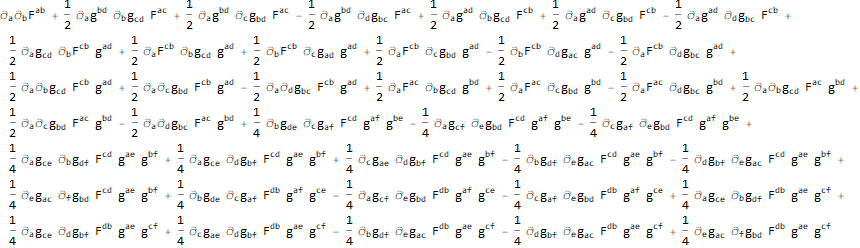

In [60]:
GammaToMetric[%]

-(BD[la, Metricg[lb, lc]] BD[ld, Metricg[uc, ub]] F[ua, ud])
------------------------------------------------------------
                             2
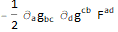

In [61]:
% // Tsimplify

(BD[la, Metricg[lb, lc]] BD[ld, Metricg[le, lf]] F[ua, ud] Metricg[ub, uf] 
 
>     Metricg[uc, ue]) / 2
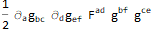

In [62]:
% /. BDinvgRule[]

In [63]:
% // Tsimplify

0

옵션으로 공변 도함수의 이름이 있다.

In [64]:
SetDefaultKind[Capital]

In [65]:
Off[CoordinateBasisFlag[Latin]]

In [66]:
DefineDerivativeOperator[CovD, "\[ScriptCapitalD]", Latin]

In [67]:
DefineMetric[Phi, "\[CapitalPhi]", Latin]

In [68]:
GammaCovD[la, lb, lc]

GammaCovD[la, lb, lc]

BD[la, Phi[lb, lc]]   BD[lb, Phi[la, lc]]   BD[lc, Phi[la, lb]]
------------------- + ------------------- - ------------------- + 
         2                     2                     2
 
    Structuref[la, lb, lc]   Structuref[lc, la, lb]   Structuref[lc, lb, la]
>   ---------------------- + ---------------------- + ----------------------
              2                        2                        2
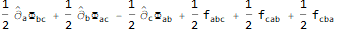

In [69]:
GammaToMetric[%, CovD]

In [70]:
RemoveMetric[Phi]; RemoveDerivativeOperator[CovD]

In [71]:
SetDefaultKind[Latin]

In [72]:
On[CoordinateBasisFlag[Latin]]

### 1.4 LDtoCD

Lie derivative를 covariant derivative로 바꾼다.

공식:
$$
  {\cal L}_v T_a^{\ b} = v^p \nabla_p T_a^{\ b}
  + (\nabla_a v^p) T_p^{\ b} - (\nabla_p v^b) T_a^{\ p}
$$

Torsion-Free가 아닌 경우:

In [73]:
TorsionFreeQ[CD] = False;

In [74]:
LDtoCD[LD[v, t[ua, ub]]]

`1` `2` `3` `4`: CD is not torsion-free  

LD[v, t[ua, ub]]

Torsion-Free인 경우:

In [75]:
TorsionFreeQ[CD] = True;

In [76]:
LDtoCD[LD[v, \[Xi][la]]]

CD[lb, ξ[la]] v[ub] + CD[la, v[ub]] ξ[lb]

In [77]:
CDtoGamma[%]

BD[lb, ξ[la]] v[ub] + BD[la, v[ub]] ξ[lb] + GammaCD[la, lc, ub] v[uc] ξ[lb] - 
 
>   GammaCD[lb, la, uc] v[ub] ξ[lc]

When $t_{ab}^{\ \ \ c}=0$ in coordinate basis, $\Gamma_{ab}^{\ \ \ c}=\Gamma_{(ab)}^{\ \ \ \ \ c}$. Then
$$
  {\cal L}_v \xi_a = v^b \partial_b \xi_a
  + \xi_b \partial_a v^b
$$

In [78]:
LDtoCD[LD[v, T[la, ub]]]

-(CD[lc, v[ub]] T[la, uc]) + CD[la, v[uc]] T[lc, ub] + CD[lc, T[la, ub]] v[uc]

In [79]:
CD[1, LD[v, T[ua, ub]]]

CD[1, LD[v, T[ua, ub]]]

In [80]:
LDtoCD[%]

CD[1, v[uc]] CD[lc, T[ua, ub]] - CD[1, T[uc, ub]] CD[lc, v[ua]] - 
 
>   CD[1, T[ua, uc]] CD[lc, v[ub]] - CD[1, CD[lc, v[ub]]] T[ua, uc] - 
 
>   CD[1, CD[lc, v[ua]]] T[uc, ub] + CD[1, CD[lc, T[ua, ub]]] v[uc]

In [81]:
LD[v, CD[la, T[ua, ub]]]

LD[v, CD[la, T[ua, ub]]]

In [82]:
LDtoCD[%]

-(CD[la, T[ua, uc]] CD[lc, v[ub]]) + CD[lc, CD[la, T[ua, ub]]] v[uc]

In [83]:
LD[v, T[lb, lc] CD[la, T[ua, ub]]]

CD[la, T[ua, ub]] LD[v, T[lb, lc]] + LD[v, CD[la, T[ua, ub]]] T[lb, lc]

In [84]:
LDtoCD[%]

-(CD[la, T[ua, ud]] CD[ld, v[ub]] T[lb, lc]) + 
 
>   CD[la, T[ua, ub]] CD[lc, v[ud]] T[lb, ld] + 
 
>   CD[la, T[ua, ub]] CD[lb, v[ud]] T[ld, lc] + 
 
>   CD[la, T[ua, ub]] CD[ld, T[lb, lc]] v[ud] + CD[ld, CD[la, T[ua, ub]]] T[lb, lc] v[ud]

변환될 CovD를 지정할 수 있다:

In [85]:
DefineDerivativeOperator[CovD, "D", Latin]

In [86]:
LD[v, T[la, lb]]

LD[v, T[la, lb]]

In [87]:
LDtoCD[LD[v, T[la, lb]]]

CD[lb, v[uc]] T[la, lc] + CD[la, v[uc]] T[lc, lb] + CD[lc, T[la, lb]] v[uc]

In [88]:
LDtoCD[LD[v, T[la, lb]], CovD]

CovD[lb, v[uc]] T[la, lc] + CovD[la, v[uc]] T[lc, lb] + CovD[lc, T[la, lb]] v[uc]

In [89]:
LDtoCD[LD[v, T[la, lb]], BD]

BD[lb, v[uc]] T[la, lc] + BD[la, v[uc]] T[lc, lb] + BD[lc, T[la, lb]] v[uc]

텐서 표현이 아니거나 CovD와 부합되지 않는 것은 변환되지 않는다:

In [90]:
LDtoCD[LD[v, something[la]]]

LD[v, something[la]]

In [91]:
LDtoCD[LD[v, BD[la, f[]]]]

LD[v, BD[la, f[]]]

In [92]:
LDtoCD[LD[v, BD[la, f[]]], BD]

LD[v, BD[la, f[]]]

In [93]:
LDtoCD[BD[la, LD[v, f[]]]]

BD[la, LD[v, f[]]]

In [94]:
LDtoCD[BD[la, LD[v, f[]]], BD]

BD[la, v[ub]] BD[lb, f[]] + BD[la, BD[lb, f[]]] v[ub]

In [95]:
LDtoCD[CovD[la, LD[v, f[]]]]

CovD[la, LD[v, f[]]]

In [96]:
LDtoCD[CD[la, LD[v, something[]]]]

CD[la, LD[v, something[]]]

In [97]:
LDtoCD[CD[la, LD[v, f[]]], CovD]

CD[la, LD[v, f[]]]

In [98]:
LDtoCD[CovD[la, LD[v, f[]]], CovD]

CovD[la, v[ub]] CovD[lb, f[]] + CovD[la, CovD[lb, f[]]] v[ub]

### 1.5 RiemannToGamma

곡률 텐서 $R_{abc}^{\ \ \ \ \ d}$, Ricci 텐서 $R_{ab}$, Scalar 곡률텐서 $R$을 connection $\Gamma_{ab}^{\ \ \ c}$로 바꾼다. 옵션으로 바꿀 텐서의 리스트와 공변 도함수의 이름이 있다.

공식:
$$
  R_{abc}^{\ \ \ \ \ d} = (\textrm{riemannSign})
  (\hat{\partial}_a \Gamma_{bc}^{\ \ \ d}
  - \hat{\partial}_b \Gamma_{ac}^{\ \ \ d}
  + \Gamma_{ap}^{\ \ \ d} \Gamma_{bc}^{\ \ \ p}
  - \Gamma_{bp}^{\ \ \ d} \Gamma_{ac}^{\ \ \ p}
  - f_{ab}^{\ \ \ p} \Gamma_{pc}^{\ \ \ d}) 
$$

Non-coordinate basis에서

In [99]:
Off[CoordinateBasisFlag]

In [100]:
RiemannToGamma[RiemannCD[la, lb, lc, ud]]

-BD[la, GammaCD[lb, lc, ud]] + BD[lb, GammaCD[la, lc, ud]] - 
 
>   GammaCD[la, le, ud] GammaCD[lb, lc, ue] + GammaCD[la, lc, ue] GammaCD[lb, le, ud] + 
 
>   GammaCD[le, lc, ud] Structuref[la, lb, ue]

Coordinate basis에서

In [101]:
On[CoordinateBasisFlag]

In [102]:
RiemannToGamma[RiemannCD[la, lb, lc, ud]]

-BD[la, GammaCD[lb, lc, ud]] + BD[lb, GammaCD[la, lc, ud]] - 
 
>   GammaCD[la, le, ud] GammaCD[lb, lc, ue] + GammaCD[la, lc, ue] GammaCD[lb, le, ud]

In [103]:
RiemannToGamma[RiemannCD[la, lb, lc, ld]]

-(GammaCD[la, le, ld] GammaCD[lb, lc, ue]) + GammaCD[la, lc, ue] GammaCD[lb, le, ld] - 
 
>   BD[la, GammaCD[lb, lc, ue]] Metricg[ld, le] + 
 
>   BD[lb, GammaCD[la, lc, ue]] Metricg[ld, le]

In [104]:
RiemannToGamma[RiemannCD[la, lb, uc, ud]]

GammaCD[la, uc, ue] GammaCD[lb, le, ud] - GammaCD[la, le, ud] GammaCD[lb, uc, ue] - 
 
>   BD[la, GammaCD[lb, le, ud]] Metricg[uc, ue] + 
 
>   BD[lb, GammaCD[la, le, ud]] Metricg[uc, ue]

In [105]:
RiemannToGamma[RiemannCD[la, lb, uc, ld]]

BD[la, GammaCD[lb, ld, uc]] - BD[lb, GammaCD[la, ld, uc]] + 
 
>   GammaCD[la, le, uc] GammaCD[lb, ld, ue] - GammaCD[la, ld, ue] GammaCD[lb, le, uc]

In [106]:
RiemannToGamma[RiemannCD[la, ub, lc, ud]]

-(GammaCD[la, le, ud] GammaCD[ub, lc, ue]) + GammaCD[la, lc, ue] GammaCD[ub, le, ud] - 
 
>   BD[la, GammaCD[le, lc, ud]] Metricg[ub, ue] + 
 
>   BD[le, GammaCD[la, lc, ud]] Metricg[ub, ue]

In [107]:
RiemannToGamma[RiemannCD[la, ub, lc, ld]]

-(GammaCD[la, le, ld] GammaCD[ub, lc, ue]) + GammaCD[la, lc, ue] GammaCD[ub, le, ld] - 
 
>   BD[la, GammaCD[le, lc, uf]] Metricg[ld, lf] Metricg[ub, ue] + 
 
>   BD[le, GammaCD[la, lc, uf]] Metricg[ld, lf] Metricg[ub, ue]

In [108]:
RiemannToGamma[RiemannCD[la, ub, uc, ud]]

GammaCD[la, uc, ue] GammaCD[ub, le, ud] - GammaCD[la, le, ud] GammaCD[ub, uc, ue] - 
 
>   BD[la, GammaCD[le, lf, ud]] Metricg[ub, ue] Metricg[uc, uf] + 
 
>   BD[le, GammaCD[la, lf, ud]] Metricg[ub, ue] Metricg[uc, uf]

In [109]:
RiemannToGamma[RiemannCD[la, ub, uc, ld]]

GammaCD[la, le, uc] GammaCD[ub, ld, ue] - GammaCD[la, ld, ue] GammaCD[ub, le, uc] + 
 
>   BD[la, GammaCD[le, ld, uc]] Metricg[ub, ue] - 
 
>   BD[le, GammaCD[la, ld, uc]] Metricg[ub, ue]

In [110]:
RiemannToGamma[RiemannCD[ua, lb, lc, ld]]

GammaCD[lb, le, ld] GammaCD[ua, lc, ue] - GammaCD[lb, lc, ue] GammaCD[ua, le, ld] + 
 
>   BD[lb, GammaCD[le, lc, uf]] Metricg[ld, lf] Metricg[ua, ue] - 
 
>   BD[le, GammaCD[lb, lc, uf]] Metricg[ld, lf] Metricg[ua, ue]

connection 계수는 proper 텐서가 아니므로 텐서 연산자가 있는 경우는 바꾸지 않는다.

In [111]:
CD[ld, RiemannCD[la, lb, lc, ud]]

CD[ld, RiemannCD[la, lb, lc, ud]]

In [112]:
RiemannToGamma[%]

CD[ld, RiemannCD[la, lb, lc, ud]]

In [113]:
BD[ld, RiemannCD[la, lb, lc, ud]]

BD[ld, RiemannCD[la, lb, lc, ud]]

In [114]:
RiemannToGamma[%]

-BD[ld, BD[la, GammaCD[lb, lc, ud]]] + BD[ld, BD[lb, GammaCD[la, lc, ud]]] + 
 
>   BD[ld, GammaCD[lb, le, ud]] GammaCD[la, lc, ue] - 
 
>   BD[ld, GammaCD[lb, lc, ue]] GammaCD[la, le, ud] - 
 
>   BD[ld, GammaCD[la, le, ud]] GammaCD[lb, lc, ue] + 
 
>   BD[ld, GammaCD[la, lc, ue]] GammaCD[lb, le, ud]

Ricci 텐서를 connection 계수로 바꿀 때도 같은 함수를 이용한다.

In [115]:
RiemannToGamma[RicciCD[la, lb]]

-BD[la, GammaCD[lc, lb, uc]] + BD[lc, GammaCD[la, lb, uc]] - 
 
>   GammaCD[la, ld, uc] GammaCD[lc, lb, ud] + GammaCD[la, lb, ud] GammaCD[lc, ld, uc]

In [116]:
RiemannToGamma[RicciCD[la, ub]]

GammaCD[la, ub, ud] GammaCD[lc, ld, uc] - GammaCD[la, ld, uc] GammaCD[lc, ub, ud] - 
 
>   BD[la, GammaCD[lc, ld, uc]] Metricg[ub, ud] + 
 
>   BD[lc, GammaCD[la, ld, uc]] Metricg[ub, ud]

In [117]:
RiemannToGamma[RicciCD[ua, lb]]

GammaCD[lc, ld, uc] GammaCD[ua, lb, ud] - GammaCD[lc, lb, ud] GammaCD[ua, ld, uc] - 
 
>   BD[lc, GammaCD[ld, lb, ud]] Metricg[ua, uc] + 
 
>   BD[lc, GammaCD[ld, lb, uc]] Metricg[ua, ud]

In [118]:
RiemannToGamma[RicciCD[ua, ub]]

-(GammaCD[lc, ub, ud] GammaCD[ua, ld, uc]) + GammaCD[lc, ld, uc] GammaCD[ua, ub, ud] - 
 
>   BD[lc, GammaCD[ld, le, ud]] Metricg[ua, uc] Metricg[ub, ue] + 
 
>   BD[lc, GammaCD[ld, le, uc]] Metricg[ua, ud] Metricg[ub, ue]

In [119]:
BD[lb, RicciCD[la, ub]]

BD[lb, RicciCD[la, ub]]

In [120]:
RiemannToGamma[%]

-(BD[la, GammaCD[lc, ld, uc]] BD[lb, Metricg[ub, ud]]) + 
 
>   BD[lb, Metricg[ub, ud]] BD[lc, GammaCD[la, ld, uc]] - 
 
>   BD[lb, GammaCD[lc, ub, ud]] GammaCD[la, ld, uc] + 
 
>   BD[lb, GammaCD[lc, ld, uc]] GammaCD[la, ub, ud] + 
 
>   BD[lb, GammaCD[la, ub, uc]] GammaCD[ld, lc, ud] - 
 
>   BD[lb, GammaCD[la, lc, ud]] GammaCD[ld, ub, uc] - 
 
>   BD[lb, BD[la, GammaCD[lc, ld, uc]]] Metricg[ub, ud] + 
 
>   BD[lb, BD[lc, GammaCD[la, ld, uc]]] Metricg[ub, ud]

Ricci 텐서만을 connection 계수로 바꾸려면 옵션에서 지정한다.

In [121]:
RiemannToGamma[RiemannCD[ua, ub, lc, ld] RicciCD[la, lb],
                {RicciCD}]

-(BD[la, GammaCD[le, lb, ue]] RiemannCD[ua, ub, lc, ld]) + 
 
>   BD[le, GammaCD[la, lb, ue]] RiemannCD[ua, ub, lc, ld] - 
 
>   GammaCD[la, lf, ue] GammaCD[le, lb, uf] RiemannCD[ua, ub, lc, ld] + 
 
>   GammaCD[la, lb, uf] GammaCD[le, lf, ue] RiemannCD[ua, ub, lc, ld]

Scalar 곡률 텐서를 connection 계수로 바꿀 때도 같은 함수를 이용한다.

In [122]:
RiemannToGamma[ScalarCD[]]

GammaCD[la, ua, ub] GammaCD[lc, lb, uc] - GammaCD[la, lb, uc] GammaCD[lc, ua, ub] - 
 
>   BD[la, GammaCD[lb, lc, ub]] Metricg[ua, uc] + 
 
>   BD[la, GammaCD[lb, lc, ua]] Metricg[ub, uc]

In [123]:
BD[la, ScalarCD[]]

BD[la, ScalarCD[]]

In [124]:
 RiemannToGamma[%]

BD[la, Metricg[uc, ud]] BD[lb, GammaCD[lc, ld, ub]] - 
 
>   BD[la, Metricg[ub, ud]] BD[lb, GammaCD[lc, ld, uc]] - 
 
>   BD[la, GammaCD[lb, uc, ud]] GammaCD[lc, ld, ub] + 
 
>   BD[la, GammaCD[lb, ub, uc]] GammaCD[ld, lc, ud] - 
 
>   BD[la, GammaCD[lb, lc, ud]] GammaCD[ld, ub, uc] + 
 
>   BD[la, GammaCD[lb, lc, ub]] GammaCD[ld, ud, uc] - 
 
>   BD[la, BD[lb, GammaCD[lc, ld, uc]]] Metricg[ub, ud] + 
 
>   BD[la, BD[lb, GammaCD[lc, ld, ub]]] Metricg[uc, ud]

Scalar 곡률 텐서만을 connection 계수로 바꾸려면 옵션에서 지정한다.

In [125]:
RiemannToGamma[ScalarCD[] RicciCD[la, lb], {ScalarCD}]

GammaCD[lc, uc, ud] GammaCD[le, ld, ue] RicciCD[la, lb] - 
 
>   GammaCD[lc, ld, ue] GammaCD[le, uc, ud] RicciCD[la, lb] - 
 
>   BD[lc, GammaCD[ld, le, ud]] Metricg[uc, ue] RicciCD[la, lb] + 
 
>   BD[lc, GammaCD[ld, le, uc]] Metricg[ud, ue] RicciCD[la, lb]

옵션으로 공변 도함수의 이름이 있다.

In [126]:
SetDefaultKind[Capital]

In [127]:
DefineDerivativeOperator[CovD, "\[ScriptCapitalD]", Latin, 
 TorsionFreeQ -> False]

In [128]:
ScalarCD[] RicciCovD[la, lb] RiemannCovD[lc, ua, ld, ub]

RicciCovD[la, lb] RiemannCovD[lc, ua, ld, ub] ScalarCD[]

In [129]:
RiemannToGamma[%, {RicciCovD}, CovD]

-(BD[la, GammaCovD[le, lb, ue]] RiemannCovD[lc, ua, ld, ub] ScalarCD[]) + 
 
>   BD[le, GammaCovD[la, lb, ue]] RiemannCovD[lc, ua, ld, ub] ScalarCD[] - 
 
>   GammaCovD[la, lf, ue] GammaCovD[le, lb, uf] RiemannCovD[lc, ua, ld, ub] ScalarCD[] + 
 
>   GammaCovD[la, lb, uf] GammaCovD[le, lf, ue] RiemannCovD[lc, ua, ld, ub] ScalarCD[]

In [130]:
RemoveDerivativeOperator[CovD]

In [131]:
SetDefaultKind[Latin]

### 1.6 RiemannToWeyl and WeylToRiemann

곡률 텐서 $R_{abc}^{\ \ \ \ \ d}$와 Weyl 텐서 $C_{abc}^{\ \ \ \ \ d}$를 서로 변환한다. 옵션으로 공변 도함수의 이름이 있다.

공식:
$$
  R_{abcd} = C_{abcd}
  + (\textrm{riemannSign}) \left(
  -\frac{1}{n-2} (g_{ac} R_{bd} - g_{ad} R_{bc}
  + g_{bd} R_{ac} - g_{bc} R_{ad})
  + \frac{1}{(n-1)(n-2)} R (g_{ac} g_{bd} - g_{ad} g_{bc})
  \right)
$$

In [132]:
Format[GetDimension[Latin]] = n;

Metricg[lb, ld] RicciCD[la, lc]    Metricg[lb, lc] RicciCD[la, ld]
-(-------------------------------) + ------------------------------- + 
              -2 + n                             -2 + n
 
    Metricg[la, ld] RicciCD[lb, lc]   Metricg[la, lc] RicciCD[lb, ld]
>   ------------------------------- - ------------------------------- + 
                -2 + n                            -2 + n
 
                                Metricg[la, ld] Metricg[lb, lc] ScalarCD[]
>   RiemannCD[la, lb, lc, ld] - ------------------------------------------ + 
                                            (-2 + n) (-1 + n)
 
    Metricg[la, lc] Metricg[lb, ld] ScalarCD[]
>   ------------------------------------------
                (-2 + n) (-1 + n)
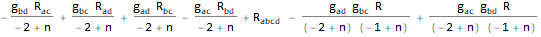

In [133]:
w2r = WeylToRiemann[WeylCD[la, lb, lc, ld]]

2 RicciCD[la, lc]   Kdelta[ub, lb] RicciCD[la, lc]
RicciCD[la, lc] + ----------------- - ------------------------------ - 
                       -2 + n                     -2 + n
 
    Metricg[la, lc] ScalarCD[]   Metricg[la, lc] ScalarCD[]
>   -------------------------- - -------------------------- + 
              -2 + n                 (-2 + n) (-1 + n)
 
    Kdelta[ub, lb] Metricg[la, lc] ScalarCD[]
>   -----------------------------------------
                (-2 + n) (-1 + n)
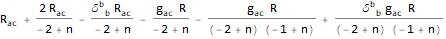

In [134]:
w2r* Metricg[ub, ud] // Absorbg

In [135]:
% /. Kdelta[ub, lb] -> GetDimension[Latin] // Simplify

0

2 RicciCD[lb, ld]   Kdelta[ua, la] RicciCD[lb, ld]
RicciCD[lb, ld] + ----------------- - ------------------------------ - 
                       -2 + n                     -2 + n
 
    Metricg[lb, ld] ScalarCD[]   Metricg[lb, ld] ScalarCD[]
>   -------------------------- - -------------------------- + 
              -2 + n                 (-2 + n) (-1 + n)
 
    Kdelta[ua, la] Metricg[lb, ld] ScalarCD[]
>   -----------------------------------------
                (-2 + n) (-1 + n)
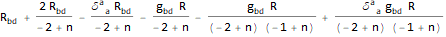

In [136]:
w2r* Metricg[ua, uc] // Absorbg

In [137]:
% /. Kdelta[ua, la] -> GetDimension[Latin] // Simplify

0

Metricg[lb, ld] RicciCD[la, lc]    Metricg[lb, lc] RicciCD[la, ld]
-(-------------------------------) + ------------------------------- + 
              -2 + n                             -2 + n
 
    Metricg[la, ld] RicciCD[lb, lc]   Metricg[la, lc] RicciCD[lb, ld]
>   ------------------------------- - ------------------------------- + 
                -2 + n                            -2 + n
 
                                Metricg[la, ld] Metricg[lb, lc] ScalarCD[]
>   RiemannCD[la, lb, lc, ld] - ------------------------------------------ + 
                                            (-2 + n) (-1 + n)
 
    Metricg[la, lc] Metricg[lb, ld] ScalarCD[]
>   ------------------------------------------
                (-2 + n) (-1 + n)
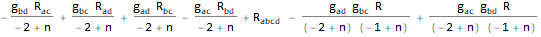

In [138]:
w2r

In [139]:
% // RiemannToWeyl

WeylCD[la, lb, lc, ld]

옵션으로 공변 도함수의 이름이 있다.

In [140]:
SetDefaultKind[Greek]

In [141]:
DefineDerivativeOperator[CovD, "\[ScriptCapitalD]", Latin, 
 TorsionFreeQ -> False]

In [142]:
Format[GetDimension[Greek]] = n;

Metricg[lν, lσ] RicciCD[lμ, lρ]    Metricg[lν, lρ] RicciCD[lμ, lσ]
-(-------------------------------) + ------------------------------- + 
              -2 + n                             -2 + n
 
    Metricg[lμ, lσ] RicciCD[lν, lρ]   Metricg[lμ, lρ] RicciCD[lν, lσ]
>   ------------------------------- - ------------------------------- + 
                -2 + n                            -2 + n
 
                                Metricg[lμ, lσ] Metricg[lν, lρ] ScalarCD[]
>   RiemannCD[lμ, lν, lρ, lσ] - ------------------------------------------ + 
                                            (-2 + n) (-1 + n)
 
    Metricg[lμ, lρ] Metricg[lν, lσ] ScalarCD[]
>   ------------------------------------------
                (-2 + n) (-1 + n)
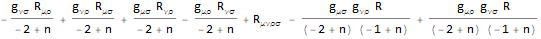

In [143]:
WeylToRiemann[WeylCD[l\[Mu], l\[Nu], l\[Rho], l\[Sigma]]]

In [144]:
% // RiemannToWeyl

WeylCD[lμ, lν, lρ, lσ]

`1` `2` `3` `4`: Latin is not a metric space  

Null[lb, ld] RicciCovD[la, lc]    Null[lb, lc] RicciCovD[la, ld]
-(------------------------------) + ------------------------------ + 
              -2 + n                            -2 + n
 
    Null[la, ld] RicciCovD[lb, lc]   Null[la, lc] RicciCovD[lb, ld]
>   ------------------------------ - ------------------------------ + 
                -2 + n                           -2 + n
 
>   RiemannCovD[la, lb, lc, ld] + 
 
     (-(Null[la, ld] Null[lb, lc]) + Null[la, lc] Null[lb, ld]) ScalarCovD[]
>    -----------------------------------------------------------------------
                                (-2 + n) (-1 + n)
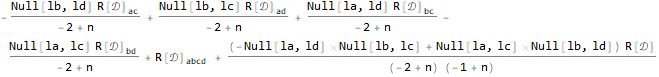

In [145]:
WeylToRiemann[WeylCovD[la, lb, lc, ld], CovD]

In [146]:
RemoveDerivativeOperator[CovD]

In [147]:
SetDefaultKind[Latin]

## 2. Set and Clear Components

In [148]:
Tdefine[e, "a"]; Tdefine[b, "a"]; Tdefine[F, "-ba"]

### 2.1 SetComponents

텐서의 성분값을 대입한다. 첫 번째 인자가 성분 텐서가 아닌 경우 두 번째 인자는 Table 표현이어야 한다.

참고: MathTensor Book

In [149]:
SetComponents[F[1, 1], 0];
SetComponents[F[2, 2], 0];
SetComponents[F[3, 3], 0];
SetComponents[F[4, 4], 0]

In [153]:
SetComponents[F[1, 4], -e[1]];
SetComponents[F[2, 4], -e[2]];
SetComponents[F[3, 4], -e[3]]

In [156]:
{F[1, 4], F[2, 4], F[3, 4]}

{-e[1], -e[2], -e[3]}

In [157]:
gaussLaw = BD[la, F[4, ua]]

BD[la, F[4, ua]]

In [158]:
SumDum[{1, 3}, gaussLaw]

BD[-3, e[3]] + BD[-2, e[2]] + BD[-1, e[1]]

In [159]:
SetComponents[F[1, 2], b[3]];
SetComponents[F[1, 3], -b[2]];
SetComponents[F[2, 3], b[1]]

In [162]:
{F[1, 2], F[1, 3], F[2, 3]}

{b[3], -b[2], b[1]}

Table 표현으로 텐서의 모든 성분값을 대입한다.

In [163]:
metric = {{1, 0, 0, 0}, {0, 1, 0, 0}, {0, 0, 1, 0}, {0, 0, 0, -1}};

In [164]:
SetComponents[Metricg[la, lb], metric]

In [165]:
Metricg[la, lc] Metricg[lb, ld] F[uc, ud]

F[uc, ud] Metricg[la, lc] Metricg[lb, ld]

In [166]:
dnF = Table[
  SumDum[{1, 4}, %], {la, -1, -4, -1}, {lb, -1, -4, -1}]

{{0, b[3], -b[2], e[1]}, {-b[3], 0, b[1], e[2]}, {b[2], -b[1], 0, e[3]}, 
 
>   {-e[1], -e[2], -e[3], 0}}

In [167]:
SetComponents[F[la, lb], dnF]

In [168]:
{F[-1, -4], F[-2, -3], F[-1, -2]}

{e[1], b[1], b[3]}

In [169]:
F[la, lb] F[ua, ub]

F[la, lb] F[ua, ub]

In [170]:
SumDum[{1, 3}, %]

2         2         2
2 b[1]  + 2 b[2]  + 2 b[3]

`SetComponents` 함수를 이용하지 않고 함수를 정의하는 방법으로도 사용할 수 있다.

In [171]:
dnF2[la_, lb_] := 
 SumDum[{1, 4}, Metricg[la, lc] Metricg[lb, ld] F[uc, ud]]

In [172]:
{dnF2[-1, -4], dnF2[-2, -3], dnF2[-1, -2]}

{e[1], b[1], b[3]}

In [173]:
eq1[lb_, ua_, ub_] := BD[lb, F[ua, ub]] /; PairQ[{lb, ub}]

In [174]:
eq2[la_, lb_, lc_] := 
 BD[la, F[lb, lc]] + BD[lb, F[lc, la]] + BD[lc, F[la, lb]]

In [175]:
SumDum[{1, 4}, eq1[lb, 1, ub]]

eq1[lb, 1, ub]

In [176]:
SumDum[{1, 4}, eq1[lb, 2, ub]]

eq1[lb, 2, ub]

In [177]:
SumDum[{1, 4}, eq1[lb, 4, ub]]

eq1[lb, 4, ub]

In [178]:
eq2[-1, -2, -3]

BD[-3, b[3]] + BD[-2, b[2]] + BD[-1, b[1]]

In [179]:
eq2[-1, -2, -4]

BD[-4, b[3]] - BD[-2, e[1]] + BD[-1, e[2]]

### 2.2 ClearComponents

텐서의 성분값을 제거한다. 인자가 성분 텐서인 경우는 그 성분의 값만 제거하고, 아닌 경우는 모든 성분의 값을 제거한다.

In [180]:
ClearComponents[F[la, lb], {4, 4}]

In [181]:
{F[-2, -1], F[1, 3]}

{F[-2, -1], -b[2]}

In [182]:
{F[-1, -1], F[-1, -2]}

{F[-1, -1], F[-1, -2]}

In [183]:
ClearComponents[F[1, 3]]

In [184]:
{F[1, 3], F[2, 3]}

{F[1, 3], b[1]}

In [185]:
ClearComponents[F[ua, ub], {4, 4}]

In [186]:
F[2, 3]

F[2, 3]

In [187]:
ClearComponents[Metricg[la, lb], {4, 4}]  (* default *)

### 2.3 Check

In [188]:
SetDimension[4]

In [189]:
SetComponents[F[1, 5], some]

`1` `2` `3` `4`: The absolute value of a component index 5 is larger than the dimension 4

In [190]:
SetComponents[F[1, -5], some]

`1` `2` `3` `4`: The absolute value of a component index -5 is larger than the dimension 4

In [191]:
ClearDimension[]

In [192]:
SetComponents[F[la], {some1, some2}]

`1` `2` `3` `4`: invalid number of indices {la} with rank 2

In [193]:
SetComponents[F[la, lb], {some1, some2}]

`1` `2` `3` `4`: incompatible components for a rank 2 

In [194]:
SetComponents[F[la, lb], {{1, 2, 3}, {4, 5, 6}}]

In [195]:
Table[F[-i, -j], {i, 2}, {j, 3}] // MatrixForm

1   2   3

4   5   6

In [196]:
ClearComponents[F[la, lb]]

`1` `2` `3` `4`: need to set dimension for the index la  

In [197]:
SetDimension[2]

In [198]:
ClearComponents[F[la, lb]]

F[-1, -1]   F[-1, -2]   3

F[-2, -1]   F[-2, -2]   6
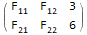

In [199]:
Table[F[-i, -j], {i, 2}, {j, 3}] // MatrixForm

In [200]:
SetDimension[3]

In [201]:
ClearComponents[F[la, lb]]

F[-1, -1]   F[-1, -2]   F[-1, -3]

F[-2, -1]   F[-2, -2]   F[-2, -3]
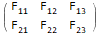

In [202]:
Table[F[-i, -j], {i, 2}, {j, 3}] // MatrixForm

In [203]:
ClearDimension[]

In [204]:
SetComponents[F[la, lb], {{1, 2}, {3, 4}, {5, 6}}]

1   2

3   4

5   6
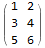

In [205]:
Table[F[-i, -j], {i, 3}, {j, 2}] // MatrixForm

In [206]:
ClearComponents[F[la, lb]]

`1` `2` `3` `4`: need to set dimension for the index la  

In [207]:
ClearComponents[F[la, lb], {3, 2}]

F[-1, -1]   F[-1, -2]

F[-2, -1]   F[-2, -2]

F[-3, -1]   F[-3, -2]
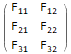

In [208]:
Table[F[-i, -j], {i, 3}, {j, 2}] // MatrixForm

In [209]:
SetDimension[2]

In [210]:
SetComponents[F[la, lb], {{1, 2}, {3, 4}}]

In [211]:
Table[F[-i, -j], {i, 2}, {j, 2}] // MatrixForm

1   2

3   4

In [212]:
ClearComponents[F[la, lb], {3, 2}]

`1` `2` `3` `4`: invalid input 3 for the dimension 2

In [213]:
ClearComponents[F[la, lb]]  (* default *)

In [214]:
ClearDimension[]  (* default *)

## 3. Pushforward, Pullback, and PushTensor

### 3.1 Pushforward

표기법:
\begin{gather*}
  M_i^{\ a} \equiv \frac{\partial y^a}{\partial x^i}, \qquad
  \xi'^a = M_i^{\ a} \xi^i, \qquad
  \xi' = M^T \xi \\
  T'^{ab} = M_i^{\ a} M_j^{\ b} T^{ij}, \qquad
  T' = M^T T M
\end{gather*}

#### 3.1.1 Maple's Differential Geometry: Pushforward Ex 1

In [215]:
fromCoSys = {x, y}; toCoSys = {u, v};

In [216]:
rightRule = {u -> Log[x^2 + y^2], v -> x/y};

In [217]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

xu

y v

2 x    1      2 y      x
{{-------, -}, {-------, -(--)}}
   2    2  y     2    2     2
  x  + y        x  + y     y
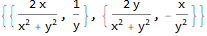

In [218]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
           {i, Length[fromCoSys]}] // Simplify

2 (a x + b y)  -(b x) + a y
{-------------, ------------}
     2    2           2
    x  + y           y
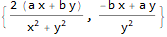

In [219]:
Transpose[MM].{a, b} // Simplify

2 (a x + b y)  -(b x) + a y
{-------------, ------------}
     2    2           2
    x  + y           y
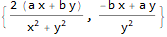

In [220]:
Pushforward[{a, b}, fromCoSys, toCoSys /. rightRule]

2 (a x + b y)  -(b x) + a y
{-------------, ------------}
     2    2           2
    x  + y           y
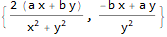

In [221]:
PushTensor[{ua}, {a, b}, fromCoSys, toCoSys, rightRule, {}]

#### 3.1.2 Maple's Differential Geometry: Pushforward Ex 4

In [222]:
fromCoSys = {x, y}; toCoSys = {r, \[Theta]};

In [223]:
leftRule = {x -> r Cos[\[Theta]], y -> r Sin[\[Theta]]};

In [224]:
rightRule = {r -> Sqrt[x^2 + y^2], \[Theta] -> 
    ArcTan[y/Sqrt[x^2 + y^2], x/Sqrt[x^2 + y^2]]};

In [225]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

xr

y θ

x           y             y             x
{{-------------, -------}, {-------------, -(-------)}}
        2    2    2    2          2    2      2    2
  Sqrt[x  + y ]  x  + y     Sqrt[x  + y ]    x  + y
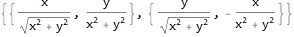

In [226]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
             {i, Length[fromCoSys]}] // Simplify

2    2
         y         2 x  + y
{-(-------------), ---------}
         2    2     3      2
   Sqrt[x  + y ]   x  + x y
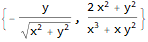

In [227]:
Transpose[MM].{y/x, -2} // Simplify

r Sin[θ]   Cos[θ] + Sec[θ]
{-(--------), ---------------}
         2           r
   Sqrt[r ]
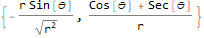

In [228]:
% /. leftRule // FullSimplify

2    2
         y         2 x  + y
{-(-------------), ---------}
         2    2     3      2
   Sqrt[x  + y ]   x  + x y
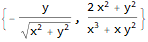

In [229]:
Pushforward[{y/x, -2}, fromCoSys, toCoSys /. rightRule]

2    2
         y         2 x  + y
{-(-------------), ---------}
         2    2     3      2
   Sqrt[x  + y ]   x  + x y
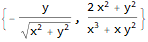

In [230]:
PushTensor[{ua}, {y/x, -2}, fromCoSys, toCoSys, rightRule, {}]

#### 3.1.3 Maple's Differential Geometry: Pushforward Ex 5

Find the tangent vector to the curve $t \rightarrow \{x=t^2, y=t^3, z=t^3\}$.

In [231]:
fromCoSys = {t}; toCoSys = {x, y, z};

In [232]:
rightRule = {x -> t^2, y -> t^3, z -> t^3};

tx

  y

  z
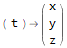

In [233]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

In [234]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
            {i, Length[fromCoSys]}] // Simplify

2     2
{{2 t, 3 t , 3 t }}

In [235]:
Transpose[MM].{1} // Simplify

2     2
{2 t, 3 t , 3 t }

In [236]:
Pushforward[{1}, fromCoSys, toCoSys /. rightRule]

2     2
{2 t, 3 t , 3 t }

In [237]:
PushTensor[{ua}, {1}, fromCoSys, toCoSys, rightRule, {}]

2     2
{2 t, 3 t , 3 t }

#### 3.1.4 Maple's Differential Geometry: Pushforward Ex 6

Find a basis for the tangent plane to the surface $z=x^3-3x y^2$.

In [238]:
fromCoSys = {x, y}; toCoSys = {x, y, z};

In [239]:
rightRule = {x -> x, y -> y, z -> x^3 - 3 x y^2};

xx

y y

  z
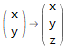

In [240]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

In [241]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
            {i, Length[fromCoSys]}] // Simplify

2    2
{{1, 0, 3 (x  - y )}, {0, 1, -6 x y}}

In [242]:
Transpose[MM].{1, 0} // Simplify

2    2
{1, 0, 3 (x  - y )}

In [243]:
Transpose[MM].{0, 1} // Simplify

{0, 1, -6 x y}

In [244]:
Pushforward[{1, 0}, fromCoSys, toCoSys /. rightRule]

2    2
{1, 0, 3 (x  - y )}

In [245]:
PushTensor[{ua}, {1, 0}, fromCoSys, toCoSys, rightRule, {}]

2    2
{1, 0, 3 (x  - y )}

In [246]:
Pushforward[{0, 1}, fromCoSys, toCoSys /. rightRule]

{0, 1, -6 x y}

In [247]:
PushTensor[{ua}, {0, 1}, fromCoSys, toCoSys, rightRule, {}]

{0, 1, -6 x y}

#### 3.1.5 Maple's Differential Geometry: Lesson 7, stereographic coordinates on $S^2$

In [248]:
fromCoSys = {u, v}; toCoSys = {x, y, z};

In [249]:
rightRule = {x -> (2 u)/(1 + u^2 + v^2),
              y -> (2 v)/(1 + u^2 + v^2),
              z -> (u^2 + v^2 - 1)/(1 + u^2 + v^2)};

ux

v y

  z
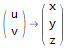

In [250]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

2      2
  2 - 2 u  + 2 v       -4 u v           4 u
{{---------------, --------------, --------------}, 
        2    2 2         2    2 2        2    2 2
  (1 + u  + v )    (1 + u  + v )   (1 + u  + v )
 
                             2    2
         -4 u v      2 (1 + u  - v )       4 v
>   {--------------, ---------------, --------------}}
           2    2 2        2    2 2         2    2 2
     (1 + u  + v )   (1 + u  + v )    (1 + u  + v )
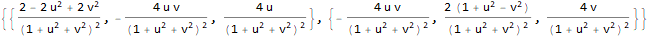

In [251]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
            {i, Length[fromCoSys]}] // Simplify

2    2                         2    2
 -4 b u v + 2 a (1 - u  + v )  2 (-2 a u v + b (1 + u  - v ))  4 (a u + b v)
{----------------------------, ------------------------------, --------------}
              2    2 2                       2    2 2                2    2 2
        (1 + u  + v )                  (1 + u  + v )           (1 + u  + v )
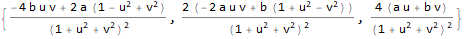

In [252]:
Transpose[MM].{a, b} // Simplify

2    2                         2    2
 -4 b u v + 2 a (1 - u  + v )  2 (-2 a u v + b (1 + u  - v ))  4 (a u + b v)
{----------------------------, ------------------------------, --------------}
              2    2 2                       2    2 2                2    2 2
        (1 + u  + v )                  (1 + u  + v )           (1 + u  + v )
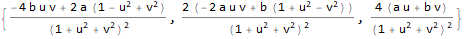

In [253]:
Pushforward[{a, b}, fromCoSys, toCoSys /. rightRule]

2    2                         2    2
 -4 b u v + 2 a (1 - u  + v )  2 (-2 a u v + b (1 + u  - v ))  4 (a u + b v)
{----------------------------, ------------------------------, --------------}
              2    2 2                       2    2 2                2    2 2
        (1 + u  + v )                  (1 + u  + v )           (1 + u  + v )
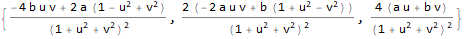

In [254]:
PushTensor[{ua}, {a, b}, fromCoSys, toCoSys, rightRule, {}]

### 3.2 Pullback

표기법:
\begin{gather*}
  M_i^{\ a} \equiv \frac{\partial y^a}{\partial x^i}, \qquad
  \omega_i = M_i^{\ a} \omega'_a, \qquad
  \omega = M \omega' \\
  T_{ij} = M_i^{\ a} M_j^{\ b} T'_{ab}, \qquad
  T = M T' M^T
\end{gather*}

#### 3.2.1 Maple's Differential Geometry: Pullback Ex 1

In [255]:
fromCoSys = {x, y}; toCoSys = {u, v, w};

In [256]:
rightRule = {u -> x + 2 y, v -> 3 x + 4 y, w -> 5 x + 6 y};

xu

y v

  w
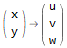

In [257]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

In [258]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
            {i, Length[fromCoSys]}] // Simplify

{{1, 3, 5}, {2, 4, 6}}

In [259]:
MM.{v, w, u} // Simplify

{5 u + v + 3 w, 2 (3 u + v + 2 w)}

In [260]:
% /. rightRule // Simplify

{23 x + 32 y, 32 x + 44 y}

In [261]:
Pullback[{v, w, u}, fromCoSys, toCoSys /. rightRule]

{5 u + v + 3 w, 2 (3 u + v + 2 w)}

In [262]:
PushTensor[{la}, {v, w, u}, toCoSys, fromCoSys, {}, rightRule]

{5 u + v + 3 w, 2 (3 u + v + 2 w)}

#### 3.2.2 Maple's Differential Geometry: Pullback Ex 3

In [263]:
fromCoSys = {r, \[Theta], \[Phi]}; toCoSys = {x, y, z};

In [264]:
rightRule = {x -> r Cos[\[Theta]] Sin[\[Phi]], 
   y -> r Sin[\[Theta]] Sin[\[Phi]], z -> r Cos[\[Theta]]};

rx

θ y

ϕ z
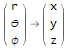

In [265]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

In [266]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
            {i, Length[fromCoSys]}] // Simplify

{{Cos[θ] Sin[ϕ], Sin[θ] Sin[ϕ], Cos[θ]}, 
 
>   {-(r Sin[θ] Sin[ϕ]), r Cos[θ] Sin[ϕ], -(r Sin[θ])}, 
 
>   {r Cos[θ] Cos[ϕ], r Cos[ϕ] Sin[θ], 0}}

{{0, r Sin[ϕ] (-x + z Sin[ϕ]), r Cos[θ] Cos[ϕ] (y Cos[θ] - x Sin[θ])}, 
 
>   {r Sin[ϕ] (x - z Sin[ϕ]), 0, 
 
         2
      -(r  Cos[ϕ] (-x + x Cos[2 θ] + y Sin[2 θ] + 2 z Sin[ϕ]))
>     --------------------------------------------------------}, 
                                 2
 
>   {-(r Cos[θ] Cos[ϕ] (y Cos[θ] - x Sin[θ])), 
 
      2
     r  Cos[ϕ] (-x + x Cos[2 θ] + y Sin[2 θ] + 2 z Sin[ϕ])
>    -----------------------------------------------------, 0}}
                               2
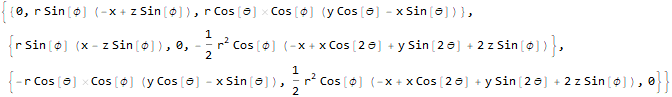

In [267]:
MM.{{0, z, -y}, {-z, 0, x}, {y, -x, 0}}.Transpose[MM] // Simplify

In [268]:
% /. rightRule // Simplify

3                              3
{{0, 0, 0}, {0, 0, -(r  Cos[θ] Cos[ϕ] Sin[ϕ])}, {0, r  Cos[θ] Cos[ϕ] Sin[ϕ], 0}}

{{0, r Sin[ϕ] (-x + z Sin[ϕ]), r Cos[θ] Cos[ϕ] (y Cos[θ] - x Sin[θ])}, 
 
>   {r Sin[ϕ] (x - z Sin[ϕ]), 0, 
 
         2
      -(r  Cos[ϕ] (-x + x Cos[2 θ] + y Sin[2 θ] + 2 z Sin[ϕ]))
>     --------------------------------------------------------}, 
                                 2
 
>   {-(r Cos[θ] Cos[ϕ] (y Cos[θ] - x Sin[θ])), 
 
      2
     r  Cos[ϕ] (-x + x Cos[2 θ] + y Sin[2 θ] + 2 z Sin[ϕ])
>    -----------------------------------------------------, 0}}
                               2
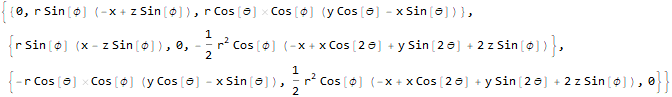

In [269]:
Pullback[{{0, z, -y}, {-z, 0, x}, {y, -x, 0}}, fromCoSys, 
 toCoSys /. rightRule]

In [270]:
% /. rightRule // Simplify

3                              3
{{0, 0, 0}, {0, 0, -(r  Cos[θ] Cos[ϕ] Sin[ϕ])}, {0, r  Cos[θ] Cos[ϕ] Sin[ϕ], 0}}

{{0, r Sin[ϕ] (-x + z Sin[ϕ]), r Cos[θ] Cos[ϕ] (y Cos[θ] - x Sin[θ])}, 
 
>   {r Sin[ϕ] (x - z Sin[ϕ]), 0, 
 
         2
      -(r  Cos[ϕ] (-x + x Cos[2 θ] + y Sin[2 θ] + 2 z Sin[ϕ]))
>     --------------------------------------------------------}, 
                                 2
 
>   {r Cos[θ] Cos[ϕ] (-(y Cos[θ]) + x Sin[θ]), 
 
      2
     r  Cos[ϕ] (-x + x Cos[2 θ] + y Sin[2 θ] + 2 z Sin[ϕ])
>    -----------------------------------------------------, 0}}
                               2
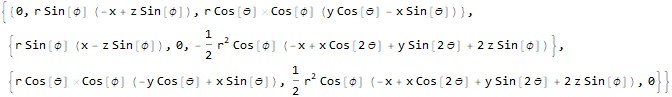

In [271]:
PushTensor[{la, 
  lb}, {{0, z, -y}, {-z, 0, x}, {y, -x, 
   0}}, toCoSys, fromCoSys, {}, rightRule]

In [272]:
% /. rightRule // Simplify

3                              3
{{0, 0, 0}, {0, 0, -(r  Cos[θ] Cos[ϕ] Sin[ϕ])}, {0, r  Cos[θ] Cos[ϕ] Sin[ϕ], 0}}

#### 3.2.3 Maple's Differential Geometry: Lesson 8

In [273]:
fromCoSys = {x, y, z}; toCoSys = {u, v};

In [274]:
rightRule = {u -> x^2 + y^2, v -> z^2 - y^2};

xu

y v

z
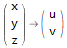

In [275]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

In [276]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
            {i, Length[fromCoSys]}] // Simplify

{{2 x, 0}, {2 y, -2 y}, {0, 2 z}}

In [277]:
MM.{v/2, -(u/2)} // Simplify

{v x, (u + v) y, -(u z)}

In [278]:
% /. rightRule // Simplify

2    2       2    2       2    2
{x (-y  + z ), y (x  + z ), -((x  + y ) z)}

In [279]:
Pullback[{v/2, -(u/2)}, fromCoSys, toCoSys /. rightRule]

{v x, (u + v) y, -(u z)}

In [280]:
PushTensor[{la}, {v/2, -(u/2)}, toCoSys, fromCoSys, {},
            rightRule]

{v x, (u + v) y, -(u z)}

#### 3.2.4 Maple's Differential Geometry: Lesson 9, Ex 2. the induced metric of a torus in $R^3$

In [281]:
fromCoSys = {u, v}; toCoSys = {x, y, z};

In [282]:
rightRule = {x -> (a + b Sin[v]) Cos[u],
              y -> (a + b Sin[v]) Sin[u],
              z -> b Cos[v]};

ux

v y

  z
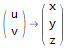

In [283]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

In [284]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
            {i, Length[fromCoSys]}] // Simplify

{{-(Sin[u] (a + b Sin[v])), Cos[u] (a + b Sin[v]), 0}, 
 
>   {b Cos[u] Cos[v], b Cos[v] Sin[u], -(b Sin[v])}}

In [285]:
MM.{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}.Transpose[MM] // Simplify

2           2
{{(a + b Sin[v]) , 0}, {0, b }}

In [286]:
Pullback[{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}, fromCoSys, 
 toCoSys /. rightRule]

2           2
{{(a + b Sin[v]) , 0}, {0, b }}

In [287]:
PushTensor[{la, 
  lb}, {{1, 0, 0}, {0, 1, 0}, {0, 0, 
   1}}, toCoSys, fromCoSys, {}, rightRule]

2           2
{{(a + b Sin[v]) , 0}, {0, b }}

### 3.3 PushTensor

For $\{x\} \rightarrow \{y\}$
\begin{gather*}
  M_i^{\ a} = \frac{\partial y^a}{\partial x^i}, \qquad
  N_a^{\ i} = \frac{\partial x^i}{\partial y^a} \\
  \xi'^a = M_i^{\ a} \xi^i, \qquad \xi' = M^T \xi \\
  \omega'^a = N_a^{\ i} \omega^i, \qquad \omega' = N \omega \\
  T'^a_{\ \ \ \ b} = M_i^{\ a} N_b^{\ j} T^i_{\ \ j}, \qquad
  T' = M^T T N^T \\
  T'^{b}_a = N_a^{\ i} M_j^{\ b} T_i^{\ j}, \qquad
  T' = N T M
\end{gather*}

#### 3.3.1 Maple's Differential Geometry: PushPullTensor Ex 1

In [288]:
fromCoSys = {x, y, z}; toCoSys = {u, v, w};

In [289]:
rightRule = {u -> x y, v -> y, w -> x z};

In [290]:
leftRule = {x -> u/v, y -> v, z -> (w v)/u};

xu

y v

z w
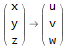

In [291]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

In [292]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
            {i, Length[fromCoSys]}] // Simplify

{{y, 0, z}, {x, 1, 0}, {0, 0, x}}

1       v w       u       w          v
{{-, 0, -(---)}, {-(--), 1, -}, {0, 0, -}}
  v        2         2      u          u
          u         v
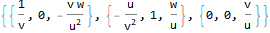

In [293]:
NN = Table[D[fromCoSys /. leftRule, toCoSys[[i]]],
            {i, Length[toCoSys]}] // Simplify

In [294]:
Transpose[MM].{{1, 0, 0}, {0, 0, 0}, {0, 0, 0}}.Transpose[NN] /. 
  leftRule // Simplify

u                   w    w
{{1, -(-), 0}, {0, 0, 0}, {-, -(-), 0}}
       v                   u    v

In [295]:
PushTensor[{ua, lb}, {{1, 0, 0}, {0, 0, 0}, {0, 0, 0}},
            fromCoSys, toCoSys, rightRule, leftRule] /. leftRule

u                   w    w
{{1, -(-), 0}, {0, 0, 0}, {-, -(-), 0}}
       v                   u    v

In [296]:
Transpose[MM].{1, 0, 0} /. leftRule

v w
{v, 0, ---}
        u

In [297]:
PushTensor[{ua}, {1, 0, 0}, fromCoSys, toCoSys, rightRule, 
  leftRule] /. leftRule

v w
{v, 0, ---}
        u

In [298]:
Transpose[MM].{0, 1, 0} /. leftRule

u
{-, 1, 0}
 v

In [299]:
PushTensor[{ua}, {0, 1, 0}, fromCoSys, toCoSys, rightRule, 
  leftRule] /. leftRule

u
{-, 1, 0}
 v

In [300]:
Transpose[MM].{0, y, 0} /. leftRule

{u, v, 0}

In [301]:
PushTensor[{ua}, {0, y, 0}, fromCoSys, toCoSys, rightRule, 
  leftRule] /. leftRule

{u, v, 0}

In [302]:
MM.{{0, 0, 1}, {0, 0, 0}, {0, 0, 0}}.Transpose[MM]

2
{{y z, 0, x y}, {x z, 0, x }, {0, 0, 0}}

In [303]:
Pullback[{{0, 0, 1}, {0, 0, 0}, {0, 0, 0}}, fromCoSys, 
 toCoSys /. rightRule]

2
{{y z, 0, x y}, {x z, 0, x }, {0, 0, 0}}

In [304]:
PushTensor[{la, 
  lb}, {{0, 0, 1}, {0, 0, 0}, {0, 0, 
   0}}, toCoSys, fromCoSys, {}, rightRule]

2
{{y z, 0, x y}, {x z, 0, x }, {0, 0, 0}}

#### 3.3.2 Maple's Differential Geometry: PushPullTensor Ex 2

In [305]:
fromCoSys = {u, v, w}; toCoSys = {x1, x2, x3, x4};

In [306]:
rightRule = {x1 -> (2 u)/(u^2 + v^2 + w^2 + 1), 
   x2 -> (2 v)/(u^2 + v^2 + w^2 + 1), 
   x3 -> (2 w)/(u^2 + v^2 + w^2 + 1), 
   x4 -> (u^2 + v^2 + w^2 - 1)/(u^2 + v^2 + w^2 + 1)};

ux1

v x2

w x3

  x4
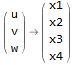

In [307]:
SequenceForm[MatrixForm[fromCoSys], "\[Rule]",
              MatrixForm[toCoSys]]

2    2    2
  2 (1 - u  + v  + w )        -4 u v               -4 u w                 4 u
{{--------------------, -------------------, -------------------, -------------------}, 
        2    2    2 2         2    2    2 2        2    2    2 2        2    2    2 2
  (1 + u  + v  + w )    (1 + u  + v  + w )   (1 + u  + v  + w )   (1 + u  + v  + w )
 
                                  2    2    2
           -4 u v         2 (1 + u  - v  + w )        -4 v w
>   {-------------------, --------------------, -------------------, 
           2    2    2 2        2    2    2 2         2    2    2 2
     (1 + u  + v  + w )   (1 + u  + v  + w )    (1 + u  + v  + w )
 
             4 v                  -4 u w               -4 v w
>    -------------------}, {-------------------, -------------------, 
           2    2    2 2          2    2    2 2        2    2    2 2
     (1 + u  + v  + w )     (1 + u  + v  + w )   (1 + u  + v  + w )
 
             2    2    2
     2 (1 + u  + v  - w )          4 w
>    --------------------, -------------------}}
           2    2    2 2         2    2    2 2
     (1 + u  + v  + w )    (1 + u  + v  + w )
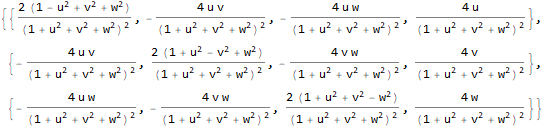

In [308]:
MM = Table[D[toCoSys /. rightRule, fromCoSys[[i]]],
            {i, Length[fromCoSys]}] // Simplify

4                               4                               4
{{-------------------, 0, 0}, {0, -------------------, 0}, {0, 0, -------------------}}
        2    2    2 2                   2    2    2 2                   2    2    2 2
  (1 + u  + v  + w )              (1 + u  + v  + w )              (1 + u  + v  + w )
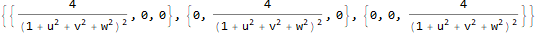

In [309]:
MM.{{1, 0, 0, 0}, {0, 1, 0, 0}, {0, 0, 1, 0}, {0, 0, 0, 1}}.Transpose[
   MM] // Simplify

4                               4                               4
{{-------------------, 0, 0}, {0, -------------------, 0}, {0, 0, -------------------}}
        2    2    2 2                   2    2    2 2                   2    2    2 2
  (1 + u  + v  + w )              (1 + u  + v  + w )              (1 + u  + v  + w )
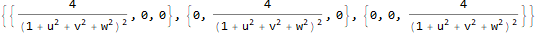

In [310]:
Pullback[{{1, 0, 0, 0}, {0, 1, 0, 0}, {0, 0, 1, 0}, {0, 0, 0, 
   1}}, fromCoSys, toCoSys /. rightRule]

4                               4                               4
{{-------------------, 0, 0}, {0, -------------------, 0}, {0, 0, -------------------}}
        2    2    2 2                   2    2    2 2                   2    2    2 2
  (1 + u  + v  + w )              (1 + u  + v  + w )              (1 + u  + v  + w )
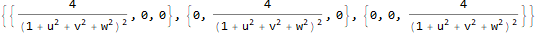

In [311]:
PushTensor[{la, 
  lb}, {{1, 0, 0, 0}, {0, 1, 0, 0}, {0, 0, 1, 0}, {0, 0, 0, 
   1}}, toCoSys, fromCoSys, {}, rightRule]

## 4. Coordinate Transformations: Ttransform

좌표변환에 따른 텐서 성분의 변환 값을 얻는다. 첫 번째와 두 번째 인자는 old와 new 텐서들이고, 세 번째와 네 번째 인자는 old와 new 좌표계에 대한 리스트 표현이다. 옵션으로 simplification을 위한 함수가 올 수 있다. 텐서에 대한 인자는 성분값을 알고 있는 경우는 텐서 표현, 변환된 값을 알고 싶은 경우는 텐서의 이름을 사용하면 된다.

For $\{x\} \rightarrow \{y\}$
\begin{gather*}
  M_a^{\ b} = \frac{\partial y^b}{\partial x^a}, \qquad
  N_a^{\ b} = \frac{\partial x^b}{\partial y^a} \\
  g'^{ab} = M_c^{\ a} M_d^{\ b} g^{cd}, \qquad
  g'_{ab} = N_a^{\ c} N_b^{\ d} g_{cd} \\
  ug' = M^T ug M, \qquad lg' = N lg N^T \\
  (M^{-1})^T ug' M^{-1} = ug, \qquad
  M lg' M^T = lg
\end{gather*}
For diffeomorphism, $N=M^{-1}$.

In [312]:
Tdefine[{oldg, newg}, "ba"]

In [313]:
SetComponents[newg[la, lb], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}]

In [314]:
SetComponents[newg[ua, ub], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}]

### 4.1 Familiar Calculation

In [315]:
leftCoSys = {r, \[Theta], \[Phi]}; rightCoSys = {x, y, z};

In [316]:
rightRule = {x -> r Sin[\[Theta]] Cos[\[Phi]], 
   y -> r Sin[\[Theta]] Sin[\[Phi]], z -> r Cos[\[Theta]]};

rx

θ y

ϕ z
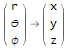

In [317]:
SequenceForm[MatrixForm[leftCoSys], "\[Rule]",
              MatrixForm[rightCoSys]]

In [318]:
MM = Table[D[rightCoSys /. rightRule, leftCoSys[[i]]],
            {i, Length[leftCoSys]}]

{{Cos[ϕ] Sin[θ], Sin[θ] Sin[ϕ], Cos[θ]}, 
 
>   {r Cos[θ] Cos[ϕ], r Cos[θ] Sin[ϕ], -(r Sin[θ])}, 
 
>   {-(r Sin[θ] Sin[ϕ]), r Cos[ϕ] Sin[θ], 0}}

#### 4.1.1 $oldg_{ab} \leftarrow newg_{ab}$

In [319]:
MM.{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}.Transpose[MM] // Simplify

2              2       2
{{1, 0, 0}, {0, r , 0}, {0, 0, r  Sin[θ] }}

In [320]:
Ttransform[oldg, newg[la, lb], leftCoSys, 
 rightCoSys /. rightRule, Simplify]

In [321]:
Table[oldg[-i, -j], {i, 3}, {j, 3}]

2              2       2
{{1, 0, 0}, {0, r , 0}, {0, 0, r  Sin[θ] }}

#### 4.1.2 $oldg_{ab} \rightarrow newg_{ab}$

In [322]:
Inverse[MM].{{1, 0, 0}, {0, r^2, 0}, {0, 0, 
    r^2 Sin[\[Theta]]^2}}.Transpose[Inverse[MM]] // Simplify

{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}

In [323]:
Ttransform[oldg[la, lb], newg, leftCoSys, 
 rightCoSys /. rightRule, Simplify]

In [324]:
Table[newg[-i, -j], {i, 3}, {j, 3}]

{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}

#### 4.1.3 $oldg^{ab} \leftarrow newg^{ab}$

2
                 -2             Csc[θ]
{{1, 0, 0}, {0, r  , 0}, {0, 0, -------}}
                                   2
                                  r
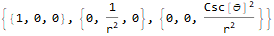

In [325]:
Transpose[Inverse[MM]].{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}.Inverse[
   MM] // Simplify

In [326]:
Ttransform[oldg, newg[ua, ub], leftCoSys, 
 rightCoSys /. rightRule, Simplify]

2
                 -2             Csc[θ]
{{1, 0, 0}, {0, r  , 0}, {0, 0, -------}}
                                   2
                                  r
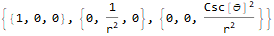

In [327]:
Table[oldg[i, j], {i, 3}, {j, 3}]

#### 4.1.4 $oldg^{ab} \rightarrow newg^{ab}$

In [328]:
Transpose[
   MM].{{1, 0, 0}, {0, 1/r^2, 0}, {0, 0, Csc[\[Theta]]^2/
    r^2}}.MM // Simplify

{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}

In [329]:
Ttransform[oldg[ua, ub], newg, leftCoSys, 
 rightCoSys /. rightRule, Simplify]

In [330]:
Table[newg[i, j], {i, 3}, {j, 3}]

{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}

### 4.2 Simple Shear

In [331]:
leftCoSys = {x, y, z}; rightCoSys = {x + K y, y, z};

xx + K y

y y

z z
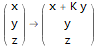

In [332]:
SequenceForm[MatrixForm[leftCoSys], "\[Rule]",
              MatrixForm[rightCoSys]]

In [333]:
MM = Table[D[rightCoSys, leftCoSys[[i]]], {i, 3}]

{{1, 0, 0}, {K, 1, 0}, {0, 0, 1}}

#### 4.2.1 $oldg_{ab} \leftarrow newg_{ab}$

In [334]:
SetComponents[newg[la, lb], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}];

In [335]:
MM.{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}.Transpose[MM]

2
{{1, K, 0}, {K, 1 + K , 0}, {0, 0, 1}}

In [336]:
Ttransform[oldg, newg[la, lb], leftCoSys, rightCoSys]

In [337]:
Table[oldg[-i, -j], {i, 3}, {j, 3}]

2
{{1, K, 0}, {K, 1 + K , 0}, {0, 0, 1}}

#### 4.2.2 $oldg_{ab} \rightarrow newg_{ab}$

In [338]:
Inverse[MM].{{1, K, 0}, {K, 1 + K^2, 0}, {0, 0, 1}}.Transpose[
  Inverse[MM]]

{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}

In [339]:
Ttransform[oldg[la, lb], newg, leftCoSys, rightCoSys]

In [340]:
Table[newg[-i, -j], {i, 3}, {j, 3}]

{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}

#### 4.2.3 $oldg^{ab} \leftarrow newg^{ab}$

In [341]:
SetComponents[newg[ua, ub], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}];

In [342]:
Transpose[Inverse[MM]].{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}.Inverse[MM]

2
{{1 + K , -K, 0}, {-K, 1, 0}, {0, 0, 1}}

In [343]:
Ttransform[oldg, newg[ua, ub], leftCoSys, rightCoSys]

In [344]:
Table[oldg[i, j], {i, 3}, {j, 3}]  (* in MathTensor *)

2
{{1 + K , -K, 0}, {-K, 1, 0}, {0, 0, 1}}

#### 4.2.4 $oldg^{ab} \rightarrow newg^{ab}$

In [345]:
Transpose[MM].{{1 + K^2, -K, 0}, {-K, 1, 0}, {0, 0, 1}}.MM // Simplify

{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}

In [346]:
Ttransform[oldg[ua, ub], newg, leftCoSys, rightCoSys]

In [347]:
Table[newg[i, j], {i, 3}, {j, 3}]

{{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}

## 5. Misc. Commands

### 5.1 Commutator

벡터들의 commutator을 얻는다. 인자로는 벡터의 리스트 또는 두 개의 벡터이다. 옵션으로 simplification을 위한 함수가 될 수 있다. 이 함수를 사용하려면 `SetCoordinates` 함수나 `InitCTensor` 함수를 이용하여 좌표계를 초기화하여야 한다. 

In [348]:
SetCoordinates[{t, x}]

In [349]:
v1 = {t, x}; v2 = {x, t}; v3 = {t, x^2};

In [350]:
Commutator[{v1, v2, v3}]

               2
[V ,V ] = {0, x }
  1  3
                2
[V ,V ] = {x - x , -t + 2 t x}
  2  3


In [351]:
Commutator[v1, v3]

2
{0, x }

In [352]:
ClearCoordinates[]  (* default *)

### 5.2 LineElement

좌표계와 metric의 입력을 받아 line element를 표시해 준다. 옵션으로 simplification 함수가 있고, default는 `Together`이다.

In [353]:
coSys = {t, r, \[Theta], \[Phi]};

In [354]:
metric = {{-E^(2 a[t, r]), 0, 0, 0},
           {0, E^(2 b[t, r]), 0, 0},
           {0, 0, r^2, 0},
           {0, 0, 0, r^2 Sin[\[Theta]]^2}};

In [355]:
LineElement[coSys, metric]

2    2 b[t, r]   2    2 a[t, r]   2    2   2    2   2       2
ds  = E          dr  - E          dt  + r  dθ  + r  dϕ  Sin[θ]